# Regression Analysis

**CAP-394-3 — Introduction to Data Science**  
**Linear Regression — Practical class**

This notebook presents a practical workflow for linear regression with Python, focusing on the main stages of a Data Science analysis:

1. Loading the dataset  
2. Exploratory data analysis  
3. Correlation among variables  
4. Visualizing the relationship between predictors and the target variable  
5. Transforming a nonlinear variable  
6. Building the regression model  
7. Interpreting the coefficients  
8. Making predictions with the fitted model  
9. Evaluating the model with regression metrics  
10. Visual diagnosis of residuals  
11. Limitations: model generalization has not yet been evaluated  
12. Next class: training, validation, and test datasets

## 1. Loading the dataset

We will use a tabular dataset available online. The target variable is `Y`, and the explanatory variables are `X1`, `X2`, `X3`, `X4`, and `X5`.

In [1]:
import pandas as pd              # Manipulação de dados tabulares (DataFrames): leitura, filtragem, transformação
import numpy as np               # Operações numéricas e vetoriais: log, sqrt, arrays, cálculos sobre resíduos
import matplotlib.pyplot as plt  # Geração de gráficos: scatter plots, histogramas, Q-Q plots

import seaborn as sns                     # Visualização estatística: heatmap e dendrograma da matriz de correlação.
import statsmodels.api as sm              # geração do gráfico Q-Q Plot para avaliar a normalidade dos resíduos.
import statsmodels.formula.api as smf     # Ajuste do modelo de regressão linear utilizando a sintaxe de fórmulas (ex.: Y ~ X1 + X2 + X3).

from sklearn.metrics import (
    r2_score,                        # Coeficiente de determinação (R²): proporção da variância explicada
    mean_squared_error,              # MSE: erro quadrático médio — penaliza erros grandes
    mean_absolute_error,             # MAE: erro absoluto médio — mais robusto a outliers que o MSE
    mean_absolute_percentage_error   # MAPE: erro percentual médio — facilita interpretação em escala relativa
)



In [2]:
# Dataset
url = "https://raw.githubusercontent.com/CDRenno/Estatistica/main/r/RegrDados.dat"
dados = pd.read_csv(url, sep="\t", decimal=".", na_values="NA")

# Show the first rows
dados.head()

,Y,X1,X2,X3,X4,X5
0,100.971593,110.668945,191.540799,0.035715,0.163621,110.630984
1,112.146916,105.870644,243.389549,0.152640,0.106897,110.488940
2,104.326049,111.513564,62.966958,0.132668,0.094935,110.983323
3,108.501621,96.003608,195.034486,0.050644,0.235669,109.651487
4,96.115165,100.543818,71.004006,0.006774,0.274924,109.598619


## 2. Exploratory data analysis

Before fitting any model, we inspect the structure of the dataset, the data types, missing values, and basic descriptive statistics.

In [3]:
# Dataset dimensions
print("Number of rows and columns:", dados.shape)

# Data types and missing values
print("\nData information:")
dados.info()

Number of rows and columns: (40, 6)

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Y       40 non-null     float64
 1   X1      40 non-null     float64
 2   X2      40 non-null     float64
 3   X3      40 non-null     float64
 4   X4      40 non-null     float64
 5   X5      40 non-null     float64
dtypes: float64(6)
memory usage: 2.0 KB


In [4]:
# Descriptive statistics
dados.describe().round(3)

,Y,X1,X2,X3,X4,X5
count,40.000,40.000,40.000,40.000,40.000,40.000
mean,104.923,105.180,222.846,0.243,0.185,110.077
std,9.131,6.020,89.065,0.435,0.072,0.582
min,83.673,93.159,62.967,0.000,0.003,108.869
25%,99.899,100.944,164.919,0.027,0.143,109.607
50%,105.639,105.600,218.817,0.058,0.176,110.019
75%,110.823,109.532,271.856,0.186,0.240,110.510
max,125.170,117.230,464.357,1.701,0.323,111.267


## 3. Correlation among variables

Correlation helps us identify possible linear associations between pairs of variables. However, correlation alone does not prove causality and does not guarantee that a regression model will provide a good fit.

In [5]:
# Correlation matrix
corr_matrix = dados.corr(numeric_only=True)
corr_matrix.round(2)

,Y,X1,X2,X3,X4,X5
Y,1.00,-0.55,0.09,0.40,-0.27,-0.46
X1,-0.55,1.00,0.12,-0.01,-0.15,0.87
X2,0.09,0.12,1.00,-0.06,-0.32,0.12
X3,0.40,-0.01,-0.06,1.00,0.28,-0.03
X4,-0.27,-0.15,-0.32,0.28,1.00,-0.22
X5,-0.46,0.87,0.12,-0.03,-0.22,1.00


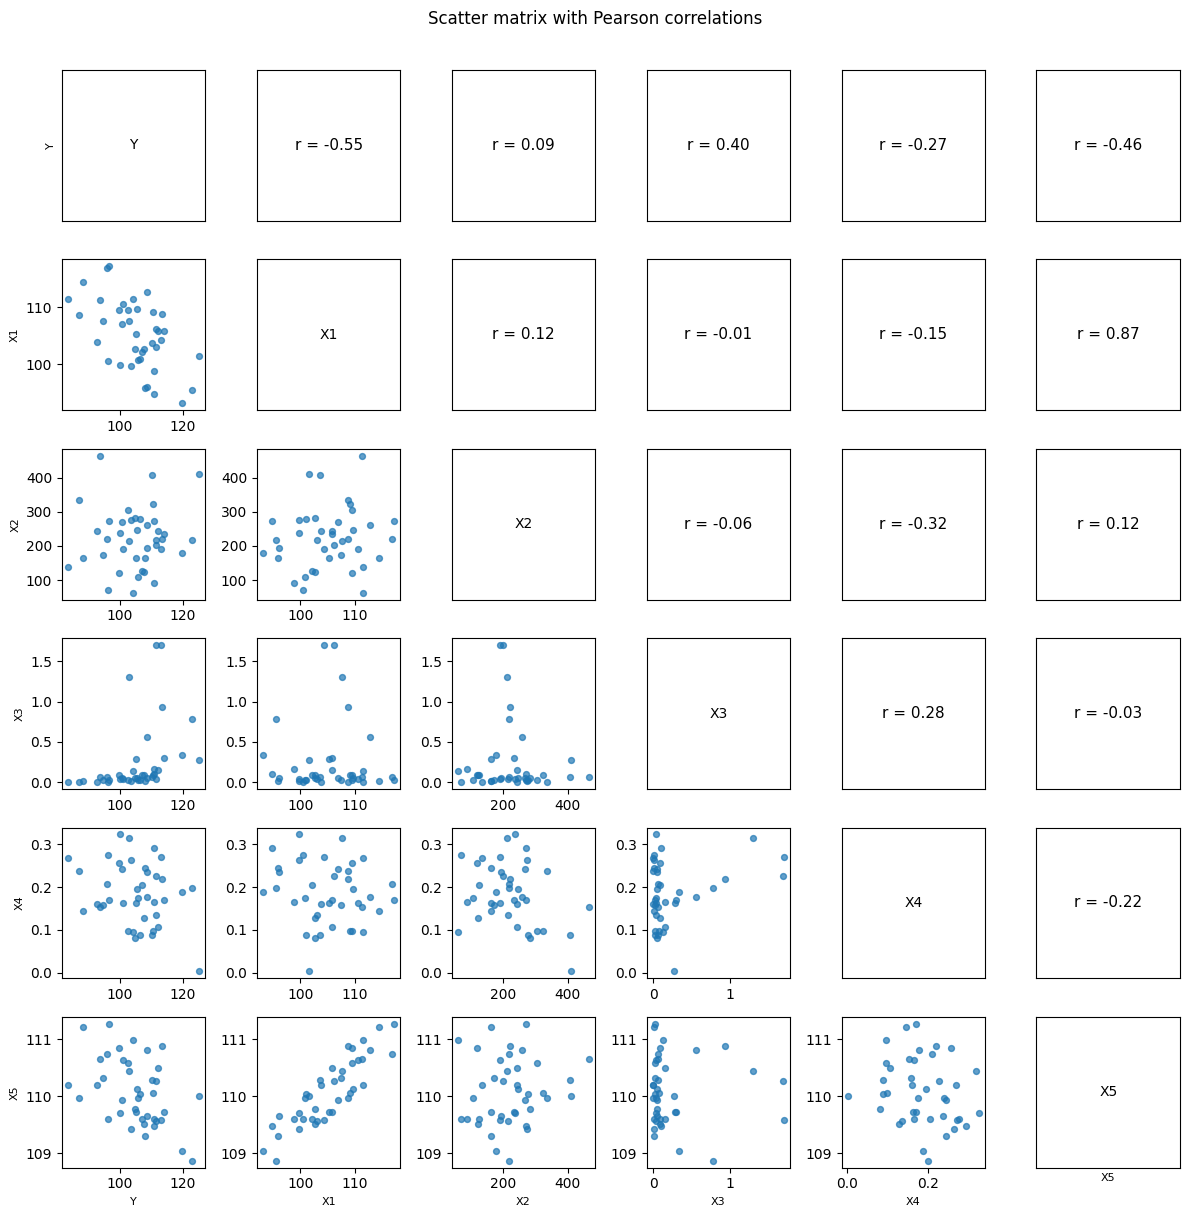

In [6]:
# Scatter matrix with correlations in the upper triangle
cols = dados.columns.tolist()
n = len(cols)

fig, axes = plt.subplots(n, n, figsize=(12, 12))

for i, col_y in enumerate(cols):
    for j, col_x in enumerate(cols):
        ax = axes[i, j]

        if i == j:
            ax.text(0.5, 0.5, col_x, ha="center", va="center", fontsize=10, transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])

        elif j > i:
            r = dados[col_x].corr(dados[col_y])
            ax.text(0.5, 0.5, f"r = {r:.2f}", ha="center", va="center", fontsize=11, transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])

        else:
            ax.scatter(dados[col_x], dados[col_y], s=18, alpha=0.7)

        if i == n - 1:
            ax.set_xlabel(col_x, fontsize=8)
        if j == 0:
            ax.set_ylabel(col_y, fontsize=8)

plt.suptitle("Scatter matrix with Pearson correlations", y=1.01)
plt.tight_layout()
plt.show()

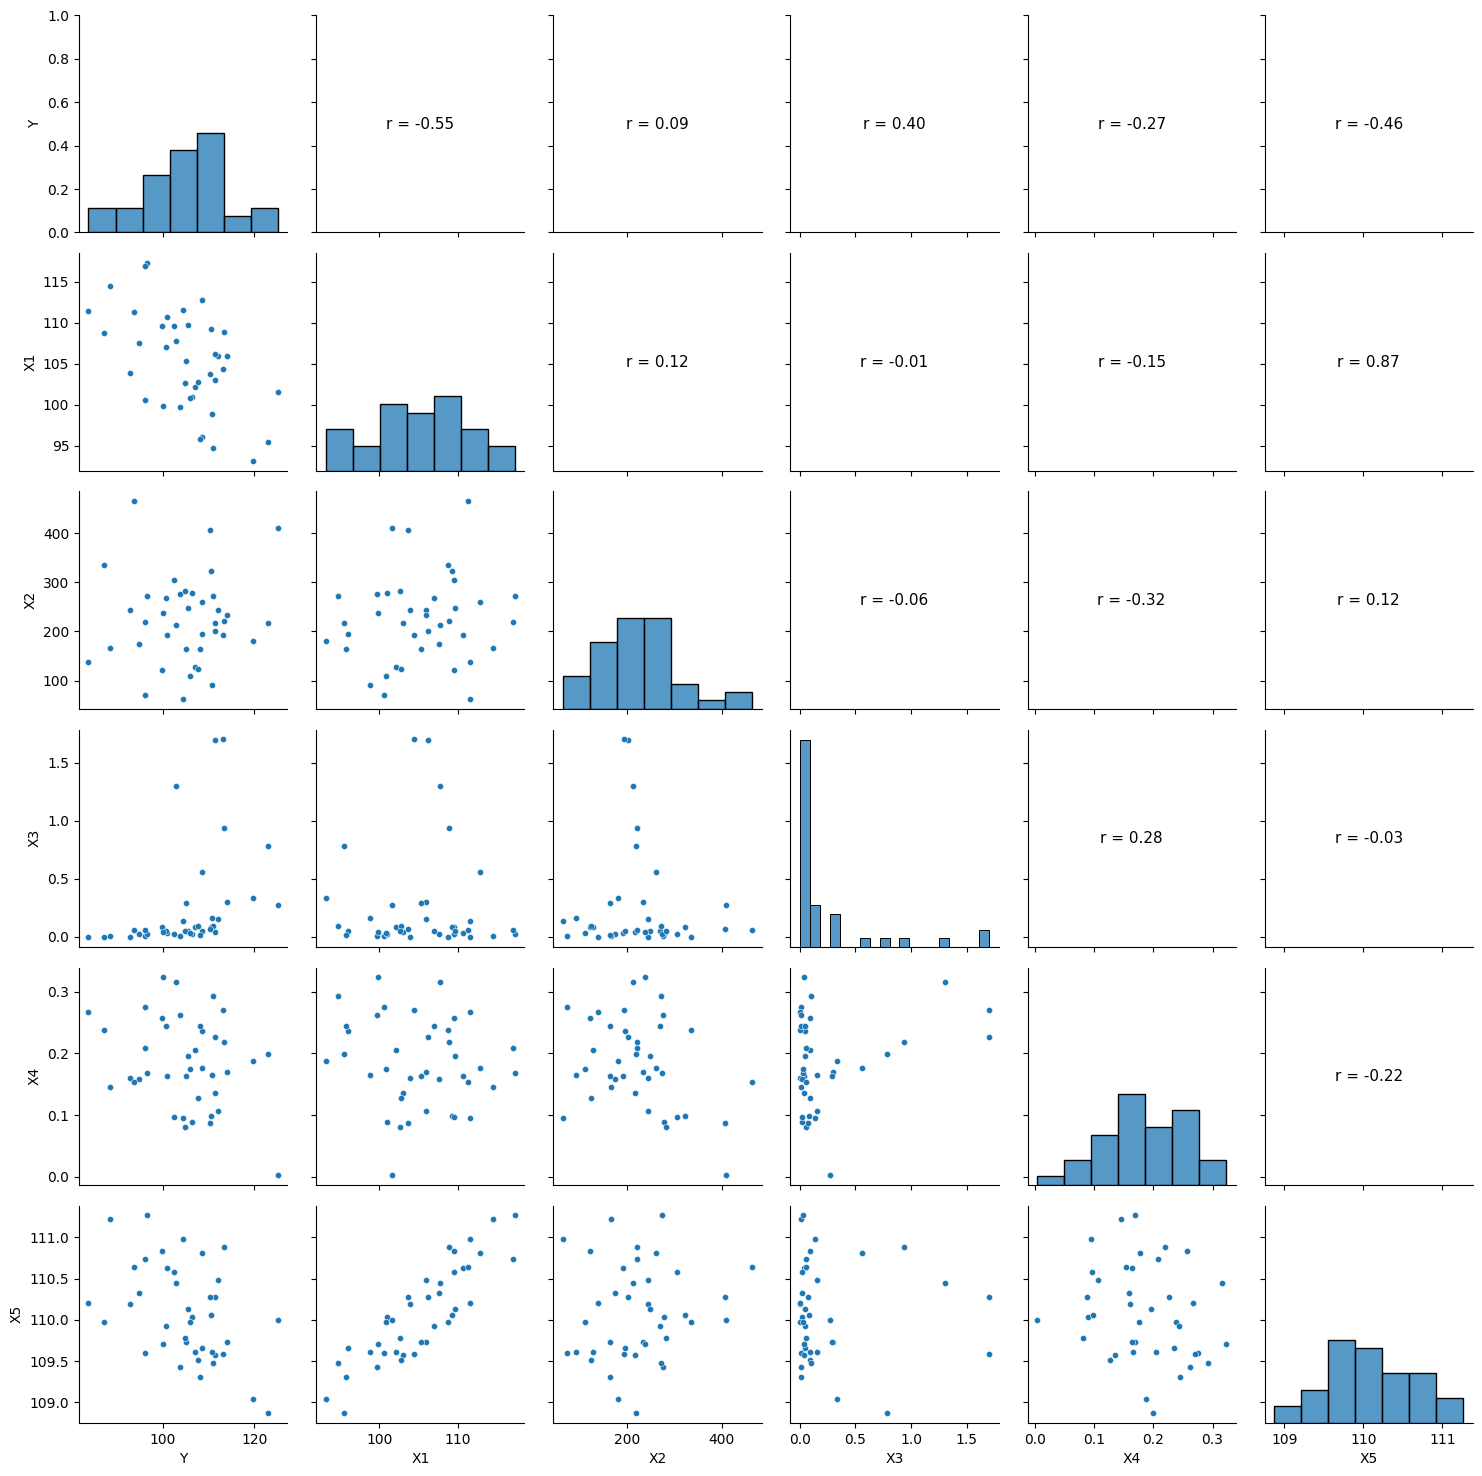

In [7]:
from scipy.stats import pearsonr
import seaborn as sns

def corrfunc(x, y, **kws):
    r, _ = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}",
                xy=(0.5, 0.5),
                xycoords=ax.transAxes,
                ha="center",
                va="center",
                fontsize=11)

g = sns.PairGrid(dados)

g.map_lower(sns.scatterplot, s=20)

g.map_diag(sns.histplot)

g.map_upper(corrfunc)

plt.show()

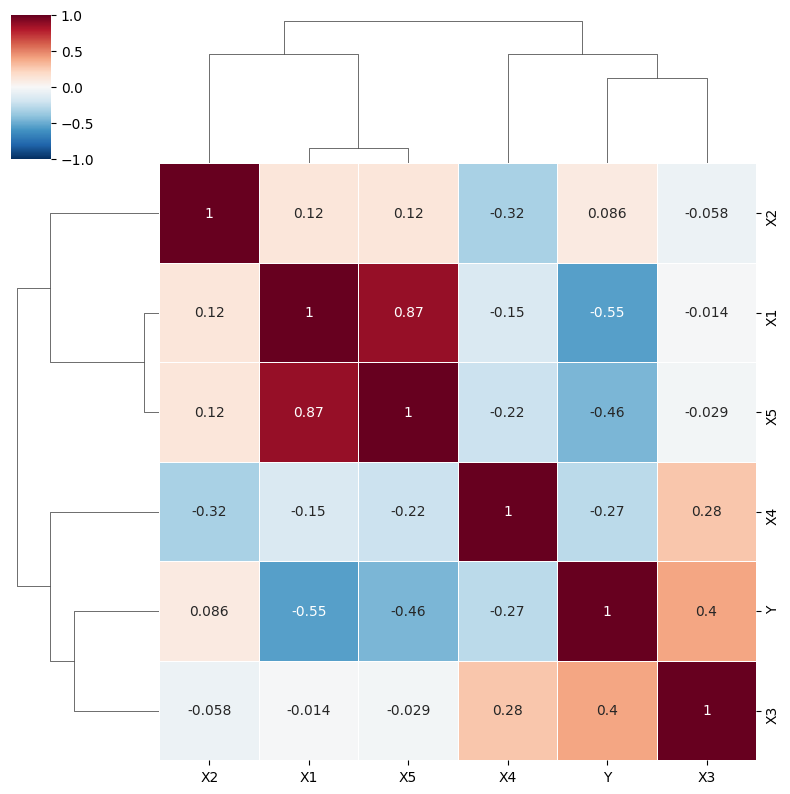

In [8]:
# =============================================================================
# Clustered correlation heatmap
# =============================================================================

corr_matrix = dados.corr(numeric_only=True)

sns.clustermap(
    corr_matrix,
    annot=True,          # mostra os coeficientes
    cmap="RdBu_r",       # azul = positivo, vermelho = negativo
    center=0,
    linewidths=0.5,
    figsize=(8, 8),
    vmin=-1,
    vmax=1
)

plt.show()

## 4. Visualizing the relationship between X and Y

The scatter plots below allow us to visually inspect whether the relationship between each predictor and the target variable `Y` appears approximately linear.

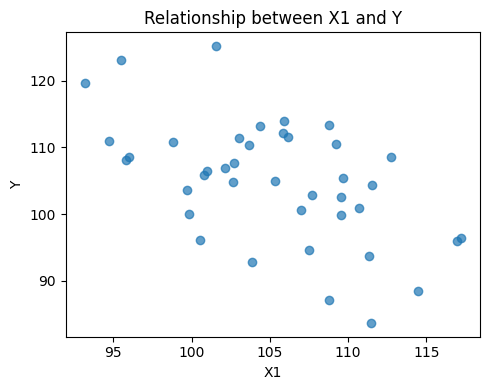

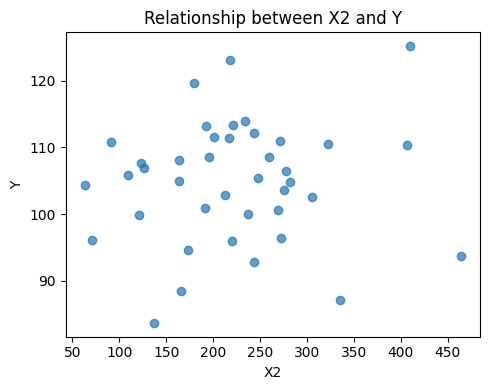

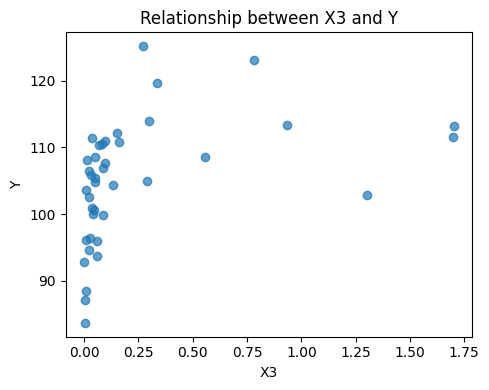

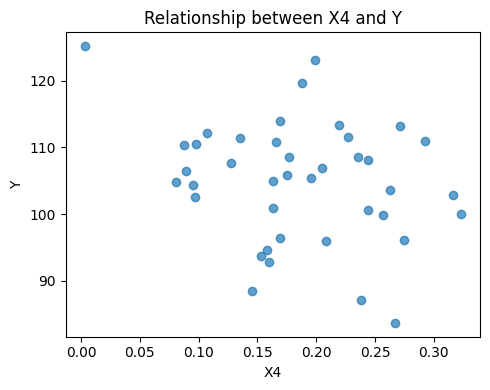

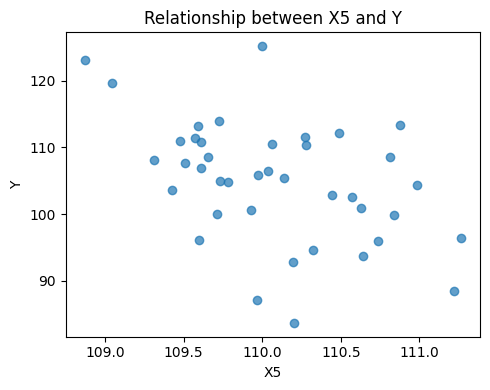

In [9]:
predictors = ["X1", "X2", "X3", "X4", "X5"]

for xi in predictors:
    plt.figure(figsize=(5, 4))
    plt.scatter(dados[xi], dados["Y"], alpha=0.7)
    plt.xlabel(xi)
    plt.ylabel("Y")
    plt.title(f"Relationship between {xi} and Y")
    plt.tight_layout()
    plt.show()

## 5. Transforming a nonlinear variable

The relationship between `X3` and `Y` is not clearly linear. A logarithmic transformation may help make this relationship more suitable for a linear regression model.

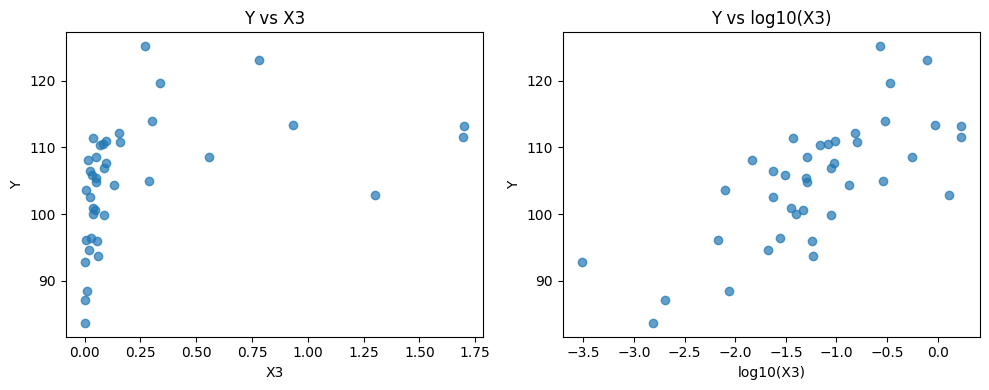

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(dados["X3"], dados["Y"], alpha=0.7)
axes[0].set_xlabel("X3")
axes[0].set_ylabel("Y")
axes[0].set_title("Y vs X3")

axes[1].scatter(np.log10(dados["X3"]), dados["Y"], alpha=0.7)
axes[1].set_xlabel("log10(X3)")
axes[1].set_ylabel("Y")
axes[1].set_title("Y vs log10(X3)")

plt.tight_layout()
plt.show()

In [11]:
# Create the transformed variable
# The original X3 is kept in the dataset for comparison, but logX3 will be used in the model.
dados["logX3"] = np.log10(dados["X3"])

dados[["X3", "logX3"]].head()

,X3,logX3
0,0.035715,-1.447150
1,0.152640,-0.816331
2,0.132668,-0.877234
3,0.050644,-1.295469
4,0.006774,-2.169124


## 6. Building the regression model

In this introductory class, we will build a linear regression model using all available observations. We will not yet split the dataset into training, validation, and test subsets.

The model uses the predictors `X1`, `X2`, `logX3`, `X4`, and `X5` to predict `Y`.

In [12]:
# Linear regression model
modelo = smf.ols("Y ~ X1 + X2 + logX3 + X4 + X5", data=dados).fit()

# Model summary
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     46.77
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           2.79e-14
Time:                        12:37:48   Log-Likelihood:                -103.44
No. Observations:                  40   AIC:                             218.9
Df Residuals:                      34   BIC:                             229.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    339.3408    200.930      1.689      0.1

## 7. Interpreting the coefficients

Each coefficient represents the expected change in `Y` associated with a one-unit increase in the corresponding predictor, assuming the other predictors remain constant.

For `logX3`, the interpretation refers to a one-unit increase in `log10(X3)`, not in the original `X3` scale.

In [ ]:
coeficientes = pd.DataFrame({
    "Coefficient": modelo.params,
    "p-value": modelo.pvalues
})

coeficientes.round(4)

,Coefficient,p-value
Intercept,339.3408,0.1004
X1,-0.7152,0.0006
X2,0.0060,0.3756
logX3,7.5333,0.0000
X4,-41.8873,0.0000
X5,-1.3059,0.5133


In [ ]:
print("Intercept:", round(modelo.params["Intercept"], 4))

for var in ["X1", "X2", "logX3", "X4", "X5"]:
    print(f"{var}: {modelo.params[var]:.4f}")

Intercept: 339.3408
X1: -0.7152
X2: 0.0060
logX3: 7.5333
X4: -41.8873
X5: -1.3059


In [15]:
# Linear regression model
modelo2 = smf.ols("Y ~ X1 + logX3 + X4", data=dados).fit()

# Model summary
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     79.10
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           6.51e-16
Time:                        12:40:18   Log-Likelihood:                -104.18
No. Observations:                  40   AIC:                             216.4
Df Residuals:                      36   BIC:                             223.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    207.8248     10.093     20.590      0.0

## 8. Prediction with the fitted model

After fitting the model, we can generate predicted values for `Y`. These predictions are based on the same data used to fit the model.

In [16]:
# Predicted values
dados["Y_pred"] = modelo2.fittedvalues

# Residuals = observed - predicted
dados["residual"] = dados["Y"] - dados["Y_pred"]

dados[["Y", "Y_pred", "residual"]].head().round(3)

,Y,Y_pred,residual
0,100.972,99.486,1.486
1,112.147,110.598,1.549
2,104.326,106.049,-1.723
3,108.502,109.487,-0.985
4,96.115,97.517,-1.402


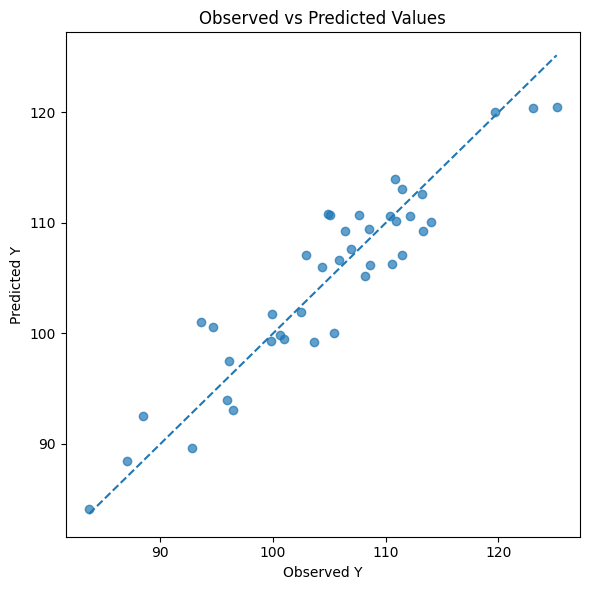

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(dados["Y"], dados["Y_pred"], alpha=0.7)

min_value = min(dados["Y"].min(), dados["Y_pred"].min())
max_value = max(dados["Y"].max(), dados["Y_pred"].max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Observed Y")
plt.ylabel("Predicted Y")
plt.title("Observed vs Predicted Values")
plt.tight_layout()
plt.show()

## 9. Evaluating the model with regression metrics

Regression metrics quantify the differences between observed and predicted values.

In this class, we calculate:

- **MSE**: Mean Squared Error  
- **RMSE**: Root Mean Squared Error  
- **MAE**: Mean Absolute Error  
- **MAPE**: Mean Absolute Percentage Error  
- **RMSLE**: Root Mean Squared Logarithmic Error  
- **R²**: Coefficient of determination  
- **Adjusted R²**: R² adjusted for the number of predictors

In [18]:
def regression_metrics(y_true, y_pred, model=None):
    """
    Calculate common regression metrics.
    MAPE requires y_true different from zero.
    RMSLE requires y_true and y_pred greater than or equal to zero.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    if np.any(y_true == 0):
        mape = np.nan
    else:
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    if np.any(y_true < 0) or np.any(y_pred < 0):
        rmsle = np.nan
    else:
        rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

    metrics = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "RMSLE": rmsle
    }

    if model is not None:
        metrics["R²"] = model.rsquared
        metrics["Adjusted R²"] = model.rsquared_adj

    return pd.DataFrame(metrics, index=["Model performance"]).T

regression_metrics(dados["Y"], dados["Y_pred"], model=modelo2).round(4)

,Model performance
MSE,10.7077
RMSE,3.2723
MAE,2.6905
MAPE (%),2.5881
RMSLE,0.0313
R²,0.8683
Adjusted R²,0.8573


## 10. Visual diagnosis of residuals

Residuals help us evaluate whether the model errors show systematic patterns.

In a well-behaved linear regression model, residuals should be approximately centered around zero, without a clear pattern in relation to the predicted values.

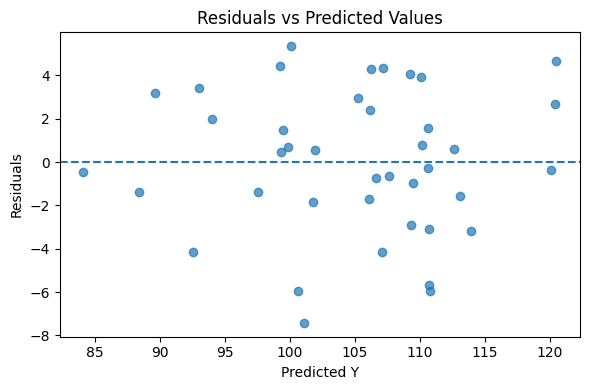

In [19]:
plt.figure(figsize=(6, 4))
plt.scatter(dados["Y_pred"], dados["residual"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Y")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()

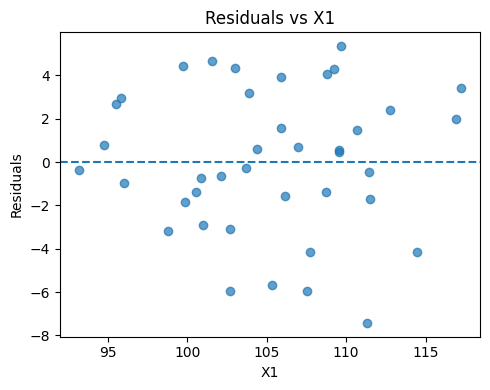

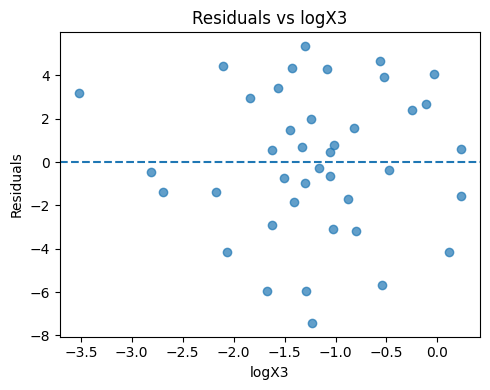

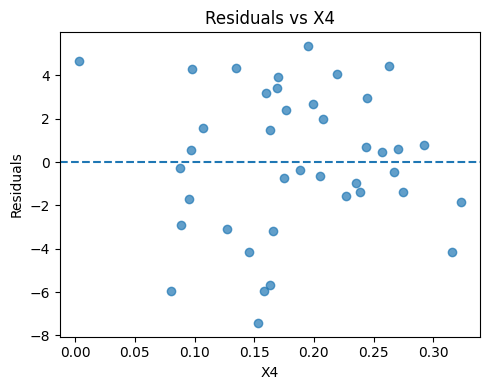

In [20]:
# Residuals vs each predictor used in the model
model_predictors = ["X1", "logX3", "X4"]

for var in model_predictors:
    plt.figure(figsize=(5, 4))
    plt.scatter(dados[var], dados["residual"], alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel(var)
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs {var}")
    plt.tight_layout()
    plt.show()

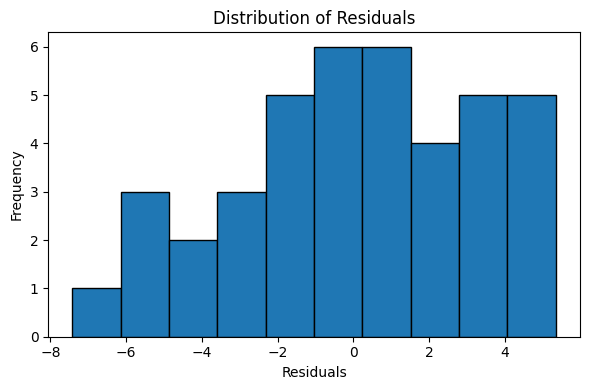

In [21]:
plt.figure(figsize=(6, 4))
plt.hist(dados["residual"], bins=10, edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.show()

<Figure size 600x600 with 0 Axes>

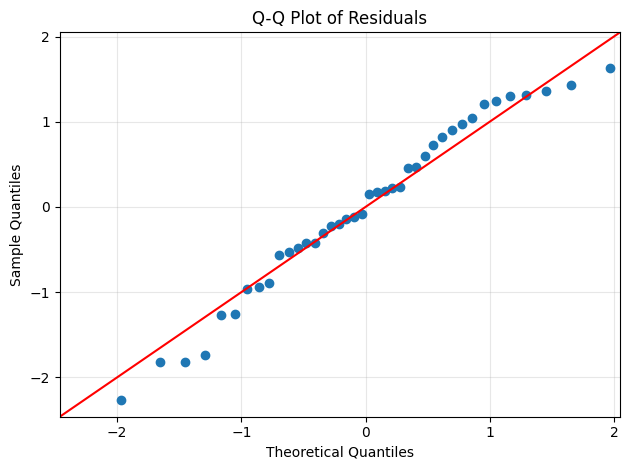

In [22]:
plt.figure(figsize=(6, 6))
sm.qqplot(dados["residual"], line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Limitations: model generalization has not yet been evaluated

The model was fitted and evaluated using the same dataset. Therefore, the metrics obtained here describe how well the model fits the available data.

However, this does **not** necessarily mean that the model will perform well on new data.

At this point, we have not yet evaluated:

- performance on unseen observations;
- overfitting;
- training and test splits;
- cross-validation;
- model generalization.

## 12. Next class: training, validation, and test datasets

In the next classes, we will study how to evaluate the predictive capacity of a model using:

- training and test datasets;
- validation strategies;
- cross-validation;
- comparison between different models;
- model selection based on generalization performance.